In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
train = pd.read_csv('../data/raw/train.csv')
test = pd.read_csv('../data/raw/test.csv')  # for final submission simulation

# Quick look
print(train.shape)


(1460, 81)


In [2]:
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [3]:
print(train.describe(include='all'))

                 Id   MSSubClass MSZoning  LotFrontage        LotArea Street  \
count   1460.000000  1460.000000     1460  1201.000000    1460.000000   1460   
unique          NaN          NaN        5          NaN            NaN      2   
top             NaN          NaN       RL          NaN            NaN   Pave   
freq            NaN          NaN     1151          NaN            NaN   1454   
mean     730.500000    56.897260      NaN    70.049958   10516.828082    NaN   
std      421.610009    42.300571      NaN    24.284752    9981.264932    NaN   
min        1.000000    20.000000      NaN    21.000000    1300.000000    NaN   
25%      365.750000    20.000000      NaN    59.000000    7553.500000    NaN   
50%      730.500000    50.000000      NaN    69.000000    9478.500000    NaN   
75%     1095.250000    70.000000      NaN    80.000000   11601.500000    NaN   
max     1460.000000   190.000000      NaN   313.000000  215245.000000    NaN   

       Alley LotShape LandContour Utili

In [4]:
print(train.head())

   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   2008        WD   

## Exploratory Data Analysis (EDA)
The goals of EDA include:
* Identifying patterns, trends, and relationships.
* Detecting outliers or anomalies.
* Checking assumptions (e.g., normality, missing values).
* Generating hypotheses for further analysis.

It can be divided into:
* Univariate analysis – examining one variable at a time.
* Bivariate analysis – exploring relationships between two variables.
* Multivariate analysis – looking at interactions among three or more variables.

### Univariate Analysis of the lable ```SalePrice```

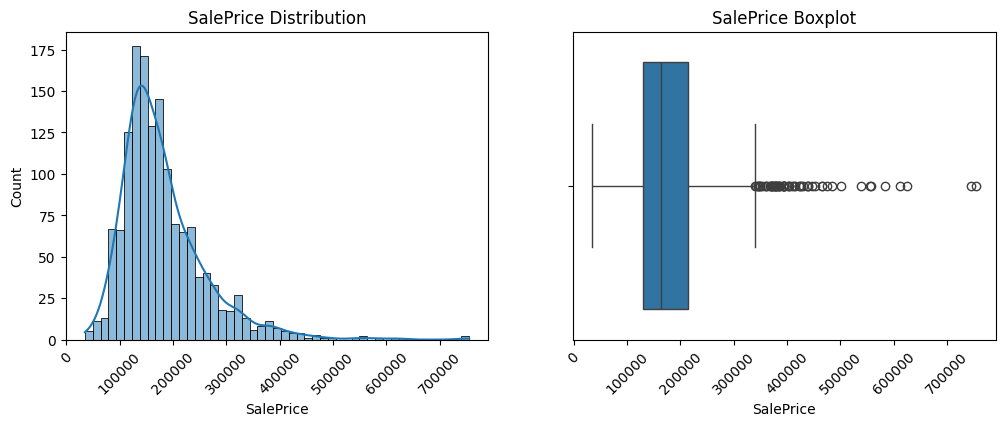

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train['SalePrice'], kde=True, ax=ax[0])
ax[0].tick_params(axis='x', rotation=45)
ax[0].set_title('SalePrice Distribution')

sns.boxplot(x=train['SalePrice'], ax=ax[1])
ax[1].tick_params(axis='x', rotation=45)
ax[1].set_title('SalePrice Boxplot')

plt.savefig('../reports/figures/target_dist.png')

### Multivariate Analysis

plan your next steps:
* Multicollinearity → Regularization (ridge, lasso), remove redundant variables, or combine them.
* Strong predictor–target correlations → Ensure these features are included and possibly transformed to improve linearity.
* Clusters of predictors → Dimensionality reduction or feature engineering (e.g., ratios, averages).
* Unexpected findings → Further exploration, data validation, or collection of additional data.
* Weak linear relationships → Consider non‑linear models or feature engineering.



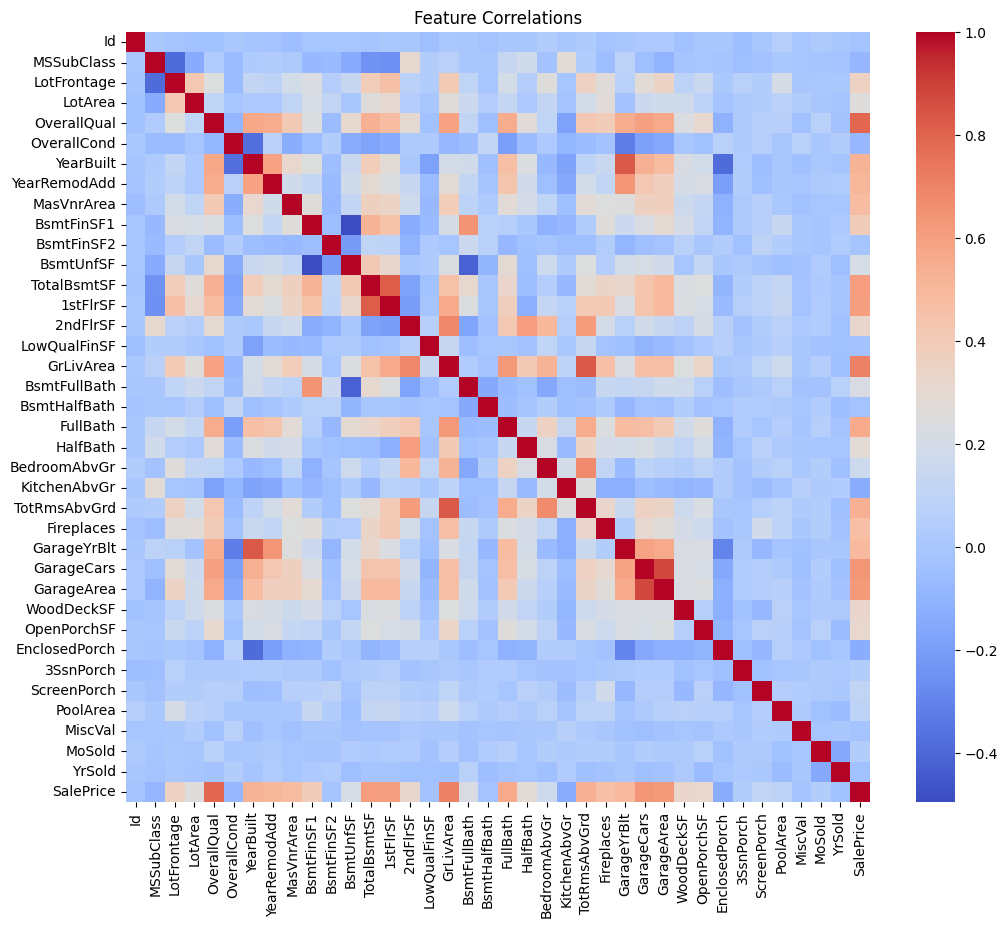

In [14]:
num_cols = train.select_dtypes(include=[np.number]).columns
corr = train[num_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=False, cmap='coolwarm')
plt.title('Feature Correlations')
plt.savefig('../reports/figures/corr_matrix.png')


In [15]:
print(corr.to_csv())

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
Id,1.0,0.01115647820138266,-0.010600688552398043,-0.03322551858568492,-0.028364753937534147,0.012608924775955575,-0.012712715387864951,-0.021997641857531825,-0.050297795171704615,-0.0050240490416607175,-0.005967671960281643,-0.007939703357717539,-0.0154145661079109,0.010496040954084946,0.005589848886159626,-0.044229958086591345,0.008272757661808138,0.002288555600834358,-0.02015474521553416,0.0055874529073555,0.0067838112842973225,0.03771855422321228,0.0029512363577296613,0.02723872440945831,-0.019771632442393293,7.239023604314056e-05,0.016569677112146127,0.017633778453767103,-0.029643197

In [4]:
corr_target = corr['SalePrice'].sort_values(ascending=False)
print(corr_target.head(10))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


## 1. Big Picture
- **Target variable**: `SalePrice`
- **Strongest linear predictors**: `OverallQual` (0.79), `GrLivArea` (0.71), `GarageCars` (0.64), `GarageArea` (0.62), `TotalBsmtSF` (0.61), `1stFlrSF` (0.61)
- **Weakest linear relationships with target**: `MSSubClass` (-0.08), `OverallCond` (-0.08), `KitchenAbvGr` (-0.14), `EnclosedPorch` (-0.13)
- **Multicollinearity**: Many size‑, quality‑, and garage‑related features are highly inter‑correlated, which will affect linear models.

## 2. Strong Predictor–Target Relationships

| Feature         | Correlation with SalePrice | Interpretation |
|-----------------|----------------------------|----------------|
| OverallQual     | 0.79                       | Overall material and finish quality – the strongest driver. |
| GrLivArea       | 0.71                       | Above‑grade living area (square feet). |
| GarageCars      | 0.64                       | Garage capacity in cars. |
| GarageArea      | 0.62                       | Garage size in square feet. |
| TotalBsmtSF     | 0.61                       | Total basement area. |
| 1stFlrSF        | 0.61                       | First floor area. |
| FullBath        | 0.56                       | Number of full bathrooms above grade. |
| TotRmsAbvGrd    | 0.53                       | Total rooms above grade (excluding bathrooms). |
| YearBuilt       | 0.52                       | Original construction date. |
| YearRemodAdd    | 0.51                       | Remodel date (same as construction if no remodeling). |
| MasVnrArea      | 0.48                       | Masonry veneer area in square feet. |
| Fireplaces      | 0.47                       | Number of fireplaces. |
| BsmtFinSF1      | 0.39                       | Type‑1 finished basement area. |
| LotFrontage     | 0.35                       | Linear feet of street frontage. |
| WoodDeckSF      | 0.32                       | Wood deck area in square feet. |
| 2ndFlrSF        | 0.32                       | Second floor area (0 if no second floor). |
| OpenPorchSF     | 0.32                       | Open porch area in square feet. |

**Story**: Price is primarily driven by **overall quality and physical size**. All top predictors reflect either the quality/age of the house or its dimensions (living area, basement, garage, etc.). Amenities like fireplaces, decks, and porches also contribute positively, though to a lesser extent.

## 3. Strong Predictor–Predictor Correlations (Multicollinearity)

| High Correlation Pair         | r       | Why it happens |
|-------------------------------|---------|----------------|
| GarageCars ↔ GarageArea       | 0.88    | Both measure garage size. |
| TotalBsmtSF ↔ 1stFlrSF        | 0.82    | Basement area often follows first‑floor footprint. |
| GrLivArea ↔ TotRmsAbvGrd      | 0.83    | More living area → more rooms. |
| YearBuilt ↔ GarageYrBlt       | 0.83    | Garages are typically built with the house. |
| GrLivArea ↔ 2ndFlrSF          | 0.69    | Larger living area often includes a second floor. |
| OverallQual ↔ YearBuilt       | 0.57    | Newer houses tend to be higher quality. |
| OverallQual ↔ GrLivArea       | 0.59    | Higher quality houses are often larger. |
| FullBath ↔ GrLivArea          | 0.63    | More living area → more bathrooms. |
| TotRmsAbvGrd ↔ BedroomAbvGr   | 0.68    | More rooms → more bedrooms. |

**Identified clusters**:
- **Size cluster**: GrLivArea, 1stFlrSF, 2ndFlrSF, TotalBsmtSF, TotRmsAbvGrd, BedroomAbvGr, FullBath, GarageArea.
- **Quality/Age cluster**: OverallQual, YearBuilt, YearRemodAdd, GarageYrBlt, MasVnrArea, Fireplaces.
- **Garage cluster**: GarageCars, GarageArea, GarageYrBlt.

## 4. Surprises and Interesting Findings

- **`KitchenAbvGr`** correlates **negatively** with price (-0.14). Counter‑intuitive – maybe multiple kitchens indicate a duplex or lower‑quality conversion. Worth investigating.
- **`OverallCond`** has nearly **zero correlation** (-0.08). Condition might have a non‑linear effect (e.g., only extremely poor condition hurts price) or be overshadowed by `OverallQual`.
- **`LotArea`** correlation is only 0.26, weaker than expected. Lot size alone is less important than house size; its effect may be captured by other features like `LotFrontage`.
- **`MSSubClass`** shows almost no linear correlation (-0.08), but it’s a categorical variable – different classes likely have very different price levels. It must be treated as a categorical feature.

## 5. Near‑Zero but Potentially Important

Features like `PoolArea`, `3SsnPorch`, `ScreenPorch`, `MiscVal` have near‑zero correlations because they are mostly zero (rare). Their **presence** might still add value. 

* Convert them to binary flags (`HasPool`, `HasPorch`, etc.).

## 6. Actionable Insights & Next Steps

### Feature Engineering
- **Reduce multicollinearity**:
  - Combine size variables: e.g., `TotalArea = GrLivArea + TotalBsmtSF`.
  - Use ratios: `BedroomProportion = BedroomAbvGr / TotRmsAbvGrd`, `LotCoverage = GrLivArea / LotArea`.
  - For garage, keep `GarageCars` (more interpretable) and drop `GarageArea`, or vice‑versa.
  - For age, create `HouseAge = YrSold - YearBuilt` and `RemodelAge = YrSold - YearRemodAdd`.
- **Binary flags for rare features**:
  - `HasPool` (PoolArea > 0)
  - `HasPorch` (any of WoodDeckSF, OpenPorchSF, EnclosedPorch, 3SsnPorch, ScreenPorch > 0)
  - `HasFireplace` (Fireplaces > 0)
  - `HasBsmt` (TotalBsmtSF > 0)
  - `HasGarage` (GarageArea > 0)
- **Address non‑linearity**:
  - For `OverallCond`, try polynomial terms or bin into categories (e.g., “poor”, “average”, “good”).
  - For `LotArea`, use log transformation (price often scales with log of lot size).
- **Properly encode categorical variables**:
  - `MSSubClass`, `MSZoning`, `Neighborhood` (if present) should be one‑hot encoded or target‑encoded.

### Modeling Recommendations
- **Linear models** (OLS, Ridge, Lasso) will be affected by multicollinearity. Use **regularization** (Ridge/Lasso) to stabilise coefficients. Lasso can also perform feature selection.
- **Tree‑based models** (Random Forest, XGBoost, LightGBM) handle multicollinearity naturally and can capture non‑linearities and interactions. They are often the best choice for tabular data like this.
- Consider **feature selection** based on domain knowledge and correlation with target, but keep weakly correlated features if they make sense – they may become important in combination.

### Further Exploration
- Create **pairplots** for the top predictors to visually check for non‑linear patterns and outliers.
- Segment analysis by `MSSubClass` or `Neighborhood` to see if relationships differ across subgroups.
- Investigate **`KitchenAbvGr`** – plot SalePrice vs. number of kitchens to understand the negative correlation.
- Check for **outliers** in `GrLivArea`, `LotArea`, etc., that might skew correlations.


### Missing Data

**Document observations:** 
e.g., PoolQC has >99% missing – likely means "no pool". Alley, Fence, MiscFeature similarly. Some numerical features like LotFrontage have meaningful missing (impute later).

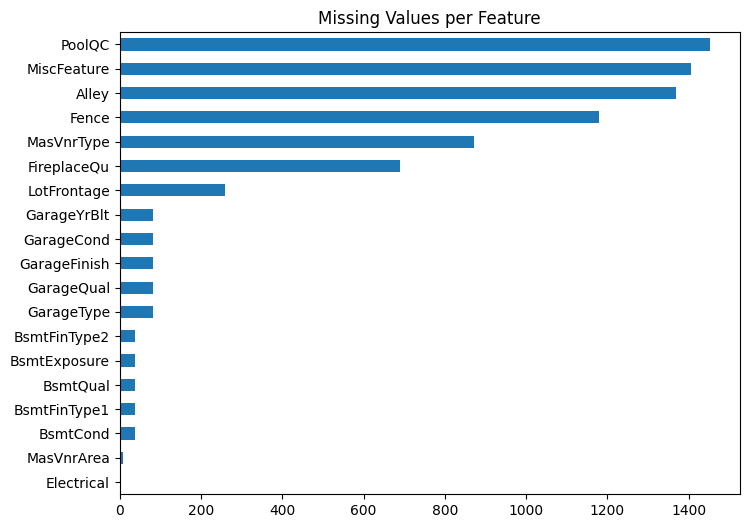

In [ ]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values()

missing.plot(kind='barh', figsize=(8, 6))
plt.title('Missing Values per Feature')

plt.savefig('../reports/figures/missing.png')

## Outlier Detection and Treatment

* Consider sensitivity analysis: Run models with and without outliers to see how much they affect results.
* Combine with scatter plots to see outliers in a bivariate context (e.g., GrLivArea vs. SalePrice). Sometimes an outlier in one dimension is not an outlier in another.
* Use statistical tests (e.g., Grubbs’ test) if you need a formal outlier detection, but visual inspection is often sufficient for EDA.
* Remember that outliers can be valuable: In fraud detection, outliers are often the cases you want to catch.


### Visual Inspection with Boxplots

#### 1. Anatomy of a Box Plot

- **Median** (Q2): The middle value of the dataset.
- **First quartile (Q1)**: The 25th percentile.
- **Third quartile (Q3)**: The 75th percentile.
- **Interquartile range (IQR)**: Q3 – Q1; it contains the middle 50% of the data.
- **Whiskers**: Typically extend to the most extreme data point that is no more than **1.5 × IQR** from the edge of the box (i.e., from Q1 or Q3).  
  - Upper whisker: max( data ≤ Q3 + 1.5×IQR )
  - Lower whisker: min( data ≥ Q1 – 1.5×IQR )
- **Outliers**: Any data points outside the whiskers are plotted individually. They are often classified as:
  - **Suspected outliers**: between 1.5×IQR and 3×IQR from the box.
  - **Extreme outliers**: beyond 3×IQR.

#### 2. Actionable Insights – What to Do About Outliers

The appropriate action depends on the **context** (domain knowledge) and the **goal** of your analysis. Here is a decision framework:

| Situation | Suggested Action |
|-----------|------------------|
| **Data entry error** | Correct if possible; otherwise remove the observation. |
| **Genuine extreme value that is rare but plausible** | **Keep** it if the model should capture such extremes. However, consider robust methods (e.g., tree‑based models, regularization) that are less sensitive to outliers. |
| **Outliers are influential and distort a linear model** | **Transform** the variable (e.g., log, square root) to reduce skewness. Alternatively, **cap (winsorize)** the values at a certain percentile (e.g., 99th percentile). |
| **Outliers represent a different population** | Consider **separate modeling** for that segment, or create a flag variable to indicate the outlier group. |
| **Outliers are few and not representative** | **Remove** them if they are not relevant to the problem you are solving (but document this decision). |
| **Unsure about the cause** | **Investigate** further: look at related variables, consult domain experts, or collect more data. |

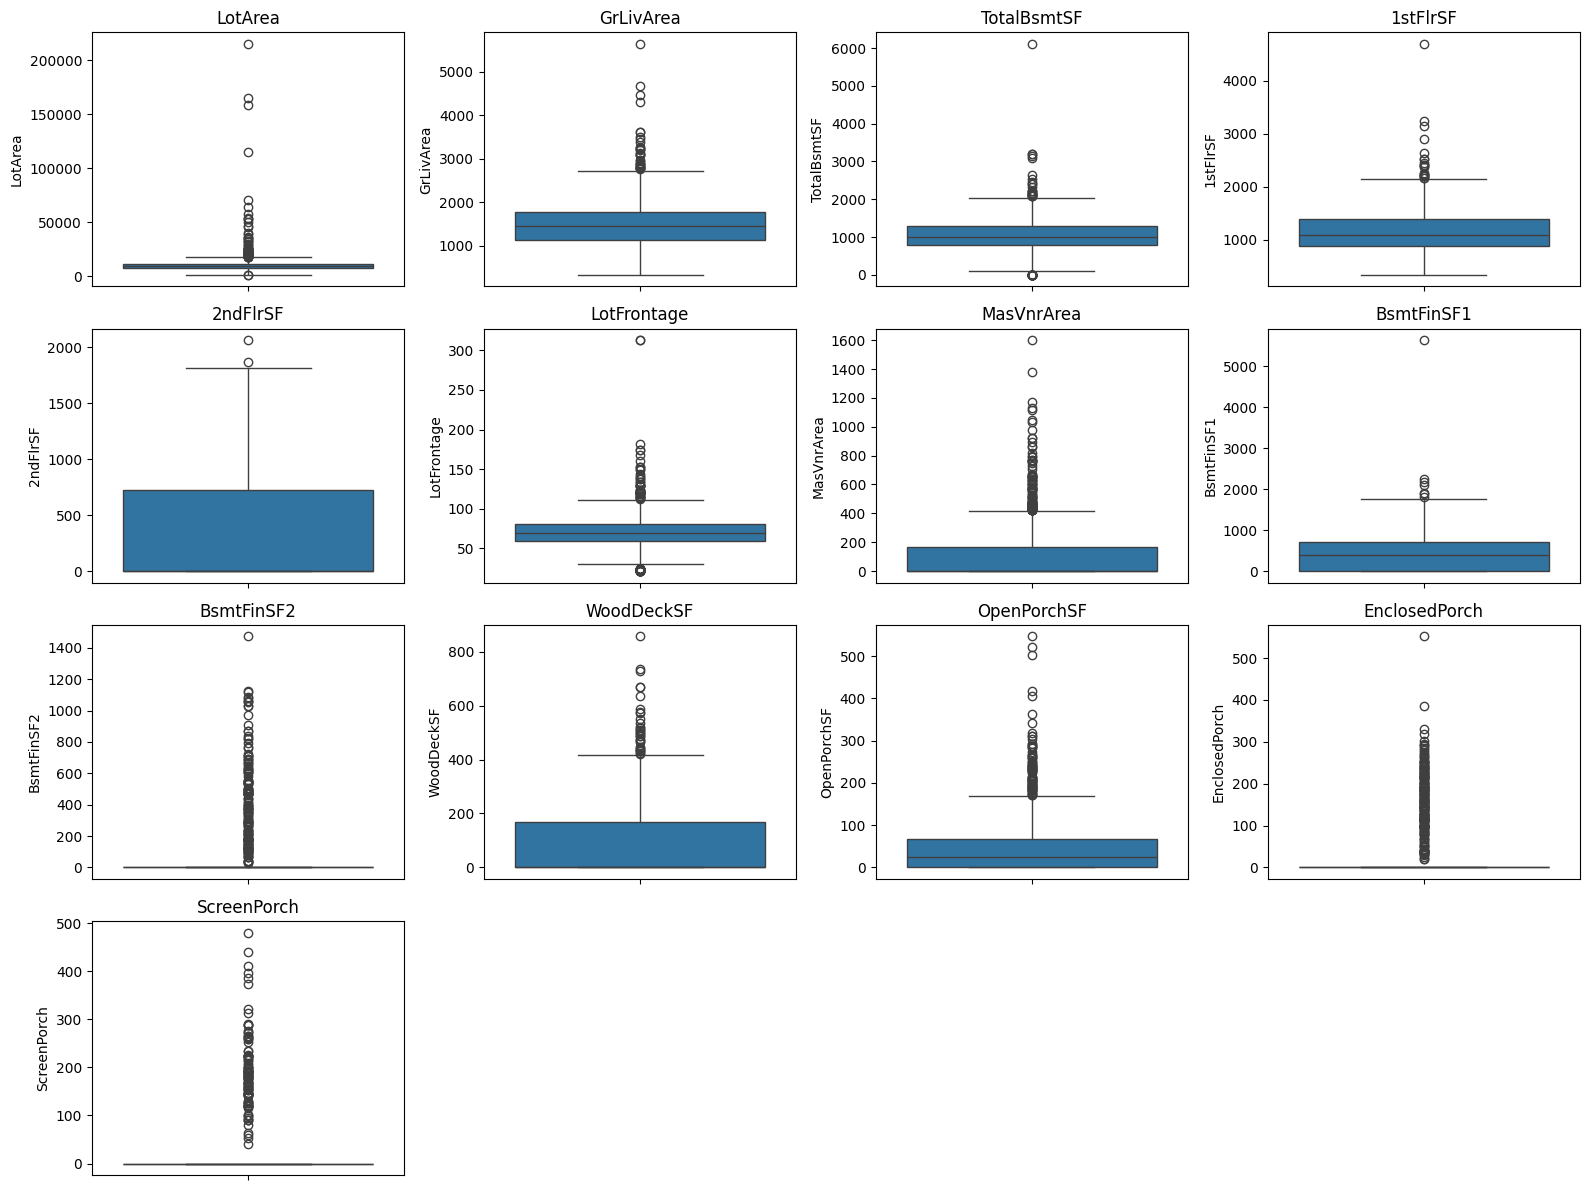

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
train = pd.read_csv('../data/raw/train.csv')


# Plot boxplots for a subset of important features
important_num = ['LotArea', 'GrLivArea', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 
                 'LotFrontage', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 
                 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', 'ScreenPorch']

# Adjust layout
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(important_num):
    if i < len(axes):
        sns.boxplot(y=train[col], ax=axes[i])
        axes[i].set_title(col)
    else:
        break

# Hide empty subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

plt.savefig('../reports/figures/outliers_boxplots.png', dpi=100)

**GrLivArea:**

the box plot shows several points above the upper whisker – these are houses with unusually large living areas.

*Investigate:* 
* Are these mansions? 
* Check if they also have high OverallQual and SalePrice.

*Decision:* 

If they are genuine luxury homes, you might keep them. But if you plan to use linear regression, these points could have high leverage. You could try a log transform of GrLivArea to reduce their influence.

**LotArea:** 

have extreme values – very large lots. 

In some neighborhoods, large lots are normal; in others, they are anomalies. 

Segmenting by Neighborhood can reveal that.

### Statistical Methods: (IQR and Z-Score)

#### 1. IQR Method:

The IQR method is based on the quartiles of the data and is robust to non‑normal distributions. It is the same rule used to draw the whiskers in a box plot.

##### How it works
1. Calculate the first quartile (Q1, 25th percentile) and third quartile (Q3, 75th percentile).
2. Compute the interquartile range:  
   `IQR = Q3 – Q1`
3. Define the lower and upper bounds (fences):
   - **Lower bound** = Q1 – 1.5 × IQR
   - **Upper bound** = Q3 + 1.5 × IQR
4. Any data point **below the lower bound** or **above the upper bound** is considered an outlier.

Sometimes a stricter threshold (3 × IQR) is used for “far outliers”.

In [ ]:
def detect_outliers_iqr(data, feature, multiplier=1.5):
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    
    outliers = data[(data[feature] < lower_bound) | (data[feature] > upper_bound)]
    
    return outliers, lower_bound, upper_bound

# Example for GrLivArea
outliers_grliv, lb_grliv, ub_grliv = detect_outliers_iqr(train, 'GrLivArea')
print(f"GrLivArea outliers count: {len(outliers_grliv)}")
print(f"Lower bound: {lb_grliv:.2f}, Upper bound: {ub_grliv:.2f}")

GrLivArea outliers count: 31
Lower bound: 158.62, Upper bound: 2747.62


#### 2. Z-Score Method (assuming normality):

The Z‑score measures how many standard deviations a data point is from the mean. It assumes the data is approximately normally distributed.



In [ ]:
from scipy import stats
threshold = 3

# Example for GrLivArea
z_scores = np.abs(stats.zscore(train['GrLivArea'].dropna()))

outliers_z = train['GrLivArea'].iloc[np.where(z_scores > threshold)]
print(f"GrLivArea outliers (z-score >3): {len(outliers_z)}")

GrLivArea outliers (z-score >3): 16


### Investigate Relationship with Target

**Observations:**

For GrLivArea > 4000, there are a few points with relatively lower SalePrice – these might be anomalies or properties with other characteristics. Check if they are errors (e.g., data entry) or genuine.

For LotArea, some extremely large lots (>100,000 sq ft) might be legitimate (e.g., farms), but they could also be outliers.

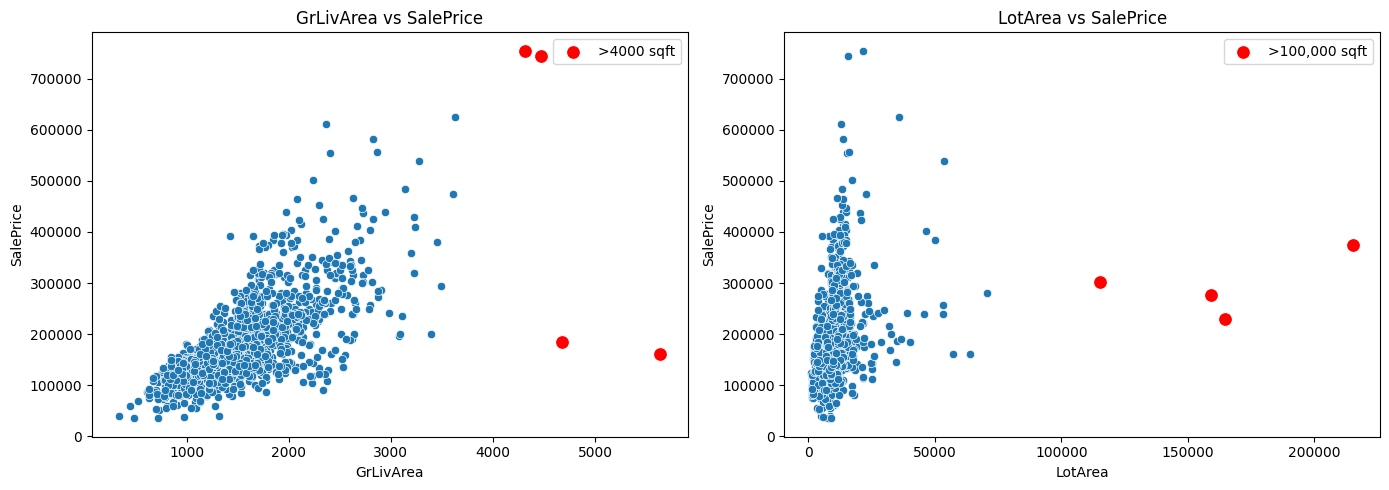

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot GrLivArea vs SalePrice
sns.scatterplot(x='GrLivArea', y='SalePrice', data=train, ax=axes[0])
axes[0].set_title('GrLivArea vs SalePrice')

# Highlight potential outliers (e.g., GrLivArea > 4000)
outliers_high_grliv = train[train['GrLivArea'] > 4000]
sns.scatterplot(x='GrLivArea', y='SalePrice', data=outliers_high_grliv, 
                color='red', s=100, ax=axes[0], label='>4000 sqft')

# Scatter plot LotArea vs SalePrice
sns.scatterplot(x='LotArea', y='SalePrice', data=train, ax=axes[1])
axes[1].set_title('LotArea vs SalePrice')

# Highlight extreme LotArea (e.g., >100,000)
outliers_lot = train[train['LotArea'] > 100000]
sns.scatterplot(x='LotArea', y='SalePrice', data=outliers_lot, 
                color='red', s=100, ax=axes[1], label='>100,000 sqft')

plt.tight_layout()
plt.savefig('../reports/figures/outliers_scatter.png', dpi=100)
plt.show()

### Decision Making: Cap or Remove?

**Common strategies:**

1. Remove if clearly erroneous or extreme and you have enough data.
2. Cap (Winsorize) – replace extreme values with a specified percentile (e.g., 99th) to reduce impact.
3. Leave as is if they are genuine and you plan to use tree-based models (robust to outliers).

For House Prices, many Kaggle solutions cap GrLivArea and LotArea at reasonable thresholds. Use domain knowledge and explore further:

In [10]:
# Check records with GrLivArea > 4000
train[train['GrLivArea'] > 4000][['Id', 'GrLivArea', 'SalePrice', 'OverallQual', 'Neighborhood']]

,Id,GrLivArea,SalePrice,OverallQual,Neighborhood
523,524,4676,184750,10,Edwards
691,692,4316,755000,10,NoRidge
1182,1183,4476,745000,10,NoRidge
1298,1299,5642,160000,10,Edwards


If you find that the very large houses are in expensive neighborhoods with high quality, they might be genuine mansions. If they have low SalePrice given their size, they could be data errors.

Example decision (based on common practice):

Cap GrLivArea at 4000 (or 99th percentile) and LotArea at 100,000.

Remove the one property with GrLivArea > 5000 and SalePrice < 200,000 (if it's an obvious outlier).

**Implementation in preprocessing:(to be added in preprocess.py or a notebook cell)**

In [11]:
from scipy.stats.mstats import winsorize

def treat_outliers(df, columns, limits=(0.01, 0.01)):
    """
    Winsorize specified columns.
    limits: (lower_fraction, upper_fraction) to cap.
    """
    df_treated = df.copy()
    for col in columns:
        df_treated[col] = winsorize(df[col], limits=limits)
    return df_treated

# Example: cap top and bottom 1% of GrLivArea and LotArea
cols_to_cap = ['GrLivArea', 'LotArea']
train_capped = treat_outliers(train, cols_to_cap, limits=(0.01, 0.01))

Alternatively, you can manually cap using np.where:

In [12]:
train['GrLivArea_capped'] = np.where(train['GrLivArea'] > 4000, 4000, train['GrLivArea'])

| Note: If you cap, do it after train/test split to avoid data leakage? Actually, capping based on full training data is acceptable as it's part of preprocessing; just ensure you apply the same thresholds to test data. You can compute percentiles from training and use them to transform both sets.

## Document Findings
From your EDA, you should have identified:

Numerical features with missing values (e.g., LotFrontage, MasVnrArea).

Categorical features with missing values (e.g., Alley, PoolQC – where missing means "none").

Features that need transformation (e.g., GrLivArea capped, maybe log transform skewed features).

Categorical features to one-hot encode.


### Outlier Analysis
GrLivArea: Identified 4 properties with >4000 sq ft. Three have high SalePrice (consistent with size), one (Id = 524) has low SalePrice relative to size. We'll cap GrLivArea at 4000 to reduce leverage.

LotArea: Several properties >100,000 sq ft. These appear to be legitimate large lots (e.g., in rural areas). We'll keep them but may consider log transformation later.

Decision: Apply winsorization to GrLivArea and LotArea at the 99th percentile. This will be implemented in the preprocessing pipeline.